### style modeling

**Zero-Inflated Poisson Style-Topic Model：数据生成过程**

**VERSION 0**
1. **Topic-level（对每个 $k,p$）**  
   - $\beta^{\text{raw}}_{k,p}\sim N(0,1)$  
   - $\beta_{k,p}=\text{softplus}(\beta^{\text{raw}}_{k,p})$  
   - $\gamma_{k,p}\sim N(0,1)$

2. **Feature-level（对每个 $p$）**  
   - $b_p\sim N(0,1)$  
   - $c_p\sim N(0,1)$

3. **Player-level（对每个 $n$）**  
   - $\eta_n\sim N(0,I_K)$  
   - $\theta_{n,k}=\dfrac{e^{\eta_{n,k}}}{\sum_{k'} e^{\eta_{n,k'}}}$

4. **Per-player-feature（对每个 $n,p$）**  
   - $\log \lambda_{n,p}= \sum_{k}\theta_{n,k}\beta_{k,p} + b_p$  
   - $g_{n,p}= \sum_{k}\theta_{n,k}\gamma_{k,p} + c_p$  
   - $\pi_{n,p}=\sigma(g_{n,p})$

5. **Observation（ZIP likelihood）**  
   - $X_{n,p}\sim \text{ZeroInflatedPoisson}(\pi_{n,p}, \lambda_{n,p})$


In [34]:
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist


def style_topic_zero_inflated_poisson_model(X, K):
    """
    Zero-Inflated Poisson Topic Model for NBA player statistics.
    This version correctly models large-count features (e.g., 0–50000)
    by using log-rate parameterization and sufficiently wide priors.

    Model structure:
    ----------------
    Players  → latent style proportions theta_n (K topics)
    Topics   → rate components (beta_k) and zero-inflation components (gamma_k)
    Features → optional bias terms (log-rate bias and gate bias)

    obs_{n,p} ~ ZIP(gate_probs_{n,p}, rate_{n,p})
    """

    N, P = X.shape   # N players, P features

    # ---------------------------------------------------------------------
    # 1. GLOBAL TOPICS: log-rate topics (beta) and gate topics (gamma)
    #    Use broader priors (Normal(0,5)) so exp(log_rate) can reach 50k+.
    # ---------------------------------------------------------------------
    with numpyro.plate("topics_rate", K):
        beta = numpyro.sample(
            "beta", 
            dist.Normal(0.0, 5.0).expand([P]).to_event(1)
        )  # shape: K × P (log-scale)

    with numpyro.plate("topics_gate", K):
        gamma = numpyro.sample(
            "gamma", 
            dist.Normal(0.0, 5.0).expand([P]).to_event(1)
        )  # shape: K × P (gate logits)

    # ---------------------------------------------------------------------
    # 2. FEATURE-LEVEL BIAS
    #    These allow each feature's baseline magnitude to be learned.
    #    For large-count NBA stats, this is essential.
    # ---------------------------------------------------------------------
    log_rate_bias = numpyro.sample(
        "log_rate_bias", 
        dist.Normal(0.0, 5.0).expand([P]).to_event(1)
    )

    gate_logit_bias = numpyro.sample(
        "gate_logit_bias", 
        dist.Normal(0.0, 5.0).expand([P]).to_event(1)
    )

    # ---------------------------------------------------------------------
    # 3. PLAYER LATENT STYLE PROPORTIONS
    #    Each player has a K-dimensional eta_n (unbounded),
    #    then mapped into a simplex by softmax → theta_n.
    # ---------------------------------------------------------------------
    with numpyro.plate("players", N):
        eta = numpyro.sample(
            "eta",
            dist.Normal(0, 5).expand([K]).to_event(1)
        )  # shape: N × K (latent style logit)

        theta = numpyro.deterministic(
            "theta",
            jnp.exp(eta) / jnp.sum(jnp.exp(eta), axis=-1, keepdims=True)
        )  # shape: N × K (style proportions)

        # ---------------------------------------------------------------
        # 4. LOG-RATE & RATE
        #    log_rate = θβ + bias
        #    rate = exp(log_rate)
        #    This allows rate to reach realistic NBA magnitudes (0–50000).
        # ---------------------------------------------------------------
        log_rate = jnp.einsum("nk,kp->np", theta, beta) + log_rate_bias
        rate = numpyro.deterministic("rate", jnp.exp(log_rate))

        # ---------------------------------------------------------------
        # 5. ZERO-INFLATION GATE
        #    gate_logit = θγ + gate_bias
        #    gate_probs = sigmoid(gate_logit)
        # ---------------------------------------------------------------
        gate_logit = jnp.einsum("nk,kp->np", theta, gamma) + gate_logit_bias
        gate_probs = numpyro.deterministic(
            "gate_probs", 
            jnp.exp(gate_logit) / (1 + jnp.exp(gate_logit))
        )

        # ---------------------------------------------------------------
        # 6. OBSERVATIONS: Zero-Inflated Poisson likelihood
        # ---------------------------------------------------------------
        numpyro.sample(
            "obs",
            dist.ZeroInflatedPoisson(gate_probs, rate).to_event(1),
            obs=X
        )


In [35]:
from numpyro.infer import SVI, Trace_ELBO
from numpyro.optim import Adam
from numpyro.infer.autoguide import AutoDiagonalNormal
import jax


def fit_style_topic_zi_svi(X, K=5, num_steps=5000, lr=1e-2, rng_seed=0):
    X = jnp.asarray(X)
    guide = AutoDiagonalNormal(style_topic_zero_inflated_poisson_model)
    optimizer = Adam(lr)
    svi = SVI(style_topic_zero_inflated_poisson_model, guide, optimizer, loss=Trace_ELBO())

    rng_key = jax.random.PRNGKey(rng_seed)
    svi_state = svi.init(rng_key, X, K)

    losses = []
    for step in range(num_steps):
        svi_state, loss_val = svi.update(svi_state, X, K)
        if step % 500 == 0:
            print(f"[SVI] step {step}, loss = {loss_val:.3f}")
        losses.append(loss_val)

    params = svi.get_params(svi_state)
    return svi, params, jnp.array(losses)


- total rebounds 球员的所有进攻篮板 + 防守篮板的累计值
- games 生涯总比赛数
- minutes played 上场时间
- assists 助攻次数
- points 总得分

其他潜在的可用特征：

- free_throw_percentage 
- field_goal_percentage 
- 3_point_percentage

In [36]:
import os
import numpy as np
import pandas as pd


# Load train / validation

data_dir = os.path.join(os.getcwd(), "Data/processed")
train_path = os.path.join(data_dir, "train_data.csv")
val_path   = os.path.join(data_dir, "validation_data.csv")

train_df = pd.read_csv(train_path)
val_df   = pd.read_csv(val_path)

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Columns:", train_df.columns.tolist())

# Select count-like features for Poisson

count_features = [
    "games",            # total games played
    "minutes_played",   # total minutes played
    "points",           # total points
    "total_rebounds",   # total rebounds
    "assists"           # total assists
]

# Sanity check: make sure all columns exist
for col in count_features:
    if col not in train_df.columns:
        raise ValueError(f"Column {col} not found in train_data.csv")
    if col not in val_df.columns:
        raise ValueError(f"Column {col} not found in validation_data.csv")

# Fill missing values with 0, cast to integer counts
X_train = train_df[count_features].fillna(0).astype(int).values  # (N_train, P)
X_val   = val_df[count_features].fillna(0).astype(int).values    # (N_val, P)

N_train, P = X_train.shape
N_val, _   = X_val.shape
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

# Concatenate train + val for one model
#    (so the NumPyro plates have fixed size)
X_all = np.concatenate([X_train, X_val], axis=0)  # (N_total, P)
N_total = X_all.shape[0]
split_idx = N_train  # first N_train rows are training players
print("X_all shape:", X_all.shape)

# standardize features for better optimization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_all_scaled = scaler.fit_transform(X_all)
X_train_scaled = X_all_scaled[:N_train]
X_val_scaled = X_all_scaled[N_train:]


Train shape: (1862, 24)
Val shape: (60, 24)
Columns: ['id', 'year', 'rank', 'overall_pick', 'team', 'player', 'college', 'years_active', 'games', 'minutes_played', 'points', 'total_rebounds', 'assists', 'field_goal_percentage', '3_point_percentage', 'free_throw_percentage', 'average_minutes_played', 'points_per_game', 'average_total_rebounds', 'average_assists', 'win_shares', 'win_shares_per_48_minutes', 'box_plus_minus', 'value_over_replacement']
X_train shape: (1862, 5)
X_val shape: (60, 5)
X_all shape: (1922, 5)


**uniform allocation**

**11个特征（Advanced）**

### training

In [41]:
import jax
import jax.numpy as jnp
from sklearn.preprocessing import MinMaxScaler
from numpyro.infer import SVI, Trace_ELBO
from numpyro.optim import Adam
from numpyro.infer.autoguide import AutoDiagonalNormal, AutoMultivariateNormal
import pickle
import os

# ==============================
# Global SVI training on X_train
# ==============================

# Hyper-parameters
K = 5           # number of style topics (tune this later)
lr = 1e-2       # learning rate
num_steps = 4000

# Convert training data to JAX array
X_train_jax = jnp.asarray(X_train)


# Guide: mean-field Gaussian over all latent variables
guide = AutoDiagonalNormal(style_topic_zero_inflated_poisson_model)

# Optimizer + SVI object
optimizer = Adam(lr)
svi = SVI(
    style_topic_zero_inflated_poisson_model,
    guide,
    optimizer,
    loss=Trace_ELBO(),
)

# Initialize SVI state
rng_key = jax.random.PRNGKey(0)
svi_state = svi.init(rng_key, X_train_jax, K)

# Run optimization
losses = []  # training loss history
for step in range(num_steps):
    svi_state, loss_val = svi.update(svi_state, X_train_jax, K)
    loss_val = float(loss_val)
    losses.append(loss_val)
    if step % 500 == 0:
        print(f"[TRAIN] step={step}, loss={loss_val:.3f}")

print("[TRAIN] SVI finished.")

# Get trained variational parameters
params = svi.get_params(svi_state)

# Save params to disk (include K in the filename to avoid confusion)
model_params_path = os.path.join(data_dir, f"svi_model_params_K{K}.pkl")
with open(model_params_path, "wb") as f:
    pickle.dump({"K": K, "params": params}, f)

print(f"[TRAIN] Saved variational params to: {model_params_path}")


[TRAIN] step=0, loss=170647008.000
[TRAIN] step=500, loss=2321831.250
[TRAIN] step=1000, loss=745884.812
[TRAIN] step=1500, loss=527722.000
[TRAIN] step=2000, loss=341806.375
[TRAIN] step=2500, loss=274778.875
[TRAIN] step=3000, loss=202780.438
[TRAIN] step=3500, loss=189542.656
[TRAIN] SVI finished.
[TRAIN] Saved variational params to: d:\Files\documents\GitHub\Unsupervised-Machine-Learning-Final-Project\Code\Data/processed\svi_model_params_K5.pkl


### Inference

In [43]:
# ============================================================
# Use saved SVI params for later inference on new data
# Load saved SVI params and rebuild global topic parameters
# ============================================================
import os
import pickle
import jax
import jax.numpy as jnp
import numpy as np
from numpyro.infer import Predictive
from numpyro.infer.autoguide import AutoDiagonalNormal

# Path to the saved variational parameters
model_params_path = os.path.join(data_dir, "svi_model_params_K5.pkl")

if not os.path.exists(model_params_path):
    raise FileNotFoundError(
        f"Saved SVI params not found at {model_params_path}. "
        "Run the global SVI training cell first to create this file."
    )

with open(model_params_path, "rb") as f:
    obj = pickle.load(f)

if isinstance(obj, dict) and "params" in obj:
    params = obj["params"]
    K = int(obj.get("K", 5))  # fallback if K not stored
else:
    params = obj
    K = 5  # TODO: change this if you trained with a different K

print(f"[LOAD] Loaded SVI params from {model_params_path} (K={K})")

# Build Predictive object with the guide and loaded params
guide = AutoDiagonalNormal(style_topic_zero_inflated_poisson_model)
X_train_jax = jnp.asarray(X_train)
N_train, P = X_train.shape

predictive_global = Predictive(
    style_topic_zero_inflated_poisson_model,
    guide=guide,
    params=params,
    num_samples=1000,
    return_sites=("beta", "gamma", "log_rate_bias", "gate_logit_bias"),
)

rng_key_post = jax.random.PRNGKey(seed=1)
posterior_global = predictive_global(rng_key_post, X_train_jax, K)

# Global parameters
beta_samples          = np.array(posterior_global["beta"])             # (S, K, P)
gamma_samples         = np.array(posterior_global["gamma"])            # (S, K, P)
log_rate_bias_samples = np.array(posterior_global["log_rate_bias"])    # (S, P)
gate_bias_samples     = np.array(posterior_global["gate_logit_bias"])  # (S, P)

beta_mean          = beta_samples.mean(axis=0)          # (K, P)
gamma_mean         = gamma_samples.mean(axis=0)         # (K, P)
log_rate_bias_mean = log_rate_bias_samples.mean(axis=0) # (P,)
gate_bias_mean     = gate_bias_samples.mean(axis=0)     # (P,)

print("[LOAD] beta_mean:", beta_mean.shape)
print("[LOAD] gamma_mean:", gamma_mean.shape)
print("[LOAD] log_rate_bias_mean:", log_rate_bias_mean.shape)
print("[LOAD] gate_bias_mean:", gate_bias_mean.shape)



[LOAD] Loaded SVI params from d:\Files\documents\GitHub\Unsupervised-Machine-Learning-Final-Project\Code\Data/processed\svi_model_params_K5.pkl (K=5)
[LOAD] beta_mean: (5, 5)
[LOAD] gamma_mean: (5, 5)
[LOAD] log_rate_bias_mean: (5,)
[LOAD] gate_bias_mean: (5,)


In [44]:
import numpyro
import numpyro.distributions as dist

def style_topic_eta_only_model(
    X_new,
    K,
    beta_fixed,
    gamma_fixed,
    log_rate_bias_fixed,
    gate_bias_fixed,
):
    """
    Conditional inference model:
    - beta_fixed, gamma_fixed, biases: has been learned global topics on training set
    - Only infer eta for new players
    """
    X_new = jnp.asarray(X_new)
    N_new, P = X_new.shape

    beta          = numpyro.deterministic("beta", beta_fixed)
    gamma         = numpyro.deterministic("gamma", gamma_fixed)
    log_rate_bias = numpyro.deterministic("log_rate_bias", log_rate_bias_fixed)
    gate_bias     = numpyro.deterministic("gate_logit_bias", gate_bias_fixed)

    with numpyro.plate("players", N_new):
        # Logistic-Normal prior over style proportions
        eta = numpyro.sample(
            "eta",
            dist.Normal(0.0, 10.0).expand([K]).to_event(1)
        )
        theta = jnp.exp(eta) / jnp.sum(jnp.exp(eta), axis=-1, keepdims=True)
        numpyro.deterministic("theta", theta)

        # Poisson rate
        log_rate = theta @ beta + log_rate_bias
        rate = jnp.exp(log_rate)
        numpyro.deterministic("rate", rate)

        # Zero-inflation gate
        gate_logit = theta @ gamma + gate_bias
        gate_probs = jnp.clip(
            jnp.exp(gate_logit) / (1.0 + jnp.exp(gate_logit)),
            a_min=1e-6,
            a_max=1.0-1e-6,
        )
        numpyro.deterministic("gate_probs", gate_probs)

        numpyro.sample(
            "obs",
            dist.ZeroInflatedPoisson(gate_probs, rate).to_event(1),
            obs=X_new,
        )


In [45]:
from numpyro.infer import SVI, Trace_ELBO, Predictive
from numpyro.optim import Adam


# Conditional SVI on VALIDATION
X_val_jax = jnp.asarray(X_val)

lr_eta = 5e-3
num_steps_eta = 2000

guide_eta = AutoDiagonalNormal(style_topic_eta_only_model)
optimizer_eta = Adam(lr_eta)
svi_eta = SVI(
    style_topic_eta_only_model,
    guide_eta,
    optimizer_eta,
    loss=Trace_ELBO(),
)

rng_key_eta = jax.random.PRNGKey(2025)
svi_state_eta = svi_eta.init(
    rng_key_eta,
    X_val_jax,
    K,
    beta_mean,
    gamma_mean,
    log_rate_bias_mean,
    gate_bias_mean,
)

val_losses = []
for step in range(num_steps_eta):
    svi_state_eta, loss_val = svi_eta.update(
        svi_state_eta,
        X_val_jax,
        K,
        beta_mean,
        gamma_mean,
        log_rate_bias_mean,
        gate_bias_mean,
    )
    val_losses.append(float(loss_val))
    if step % 500 == 0:
        print(f"[VAL SVI] step={step}, loss={loss_val:.3f}")

params_eta = svi_eta.get_params(svi_state_eta)

# Posterior for val players
predictive_eta = Predictive(
    style_topic_eta_only_model,
    guide=guide_eta,
    params=params_eta,
    num_samples=500,
)
rng_key_post_eta = jax.random.PRNGKey(2026)
posterior_val = predictive_eta(
    rng_key_post_eta,
    X_val_jax,
    K,
    beta_mean,
    gamma_mean,
    log_rate_bias_mean,
    gate_bias_mean,
)

theta_val = np.array(posterior_val["theta"]).mean(axis=0)       # (N_val, K)
rate_val  = np.array(posterior_val["rate"]).mean(axis=0)        # (N_val, P)
gate_val  = np.array(posterior_val["gate_probs"]).mean(axis=0)  # (N_val, P)

print("theta_val shape:", theta_val.shape)


[VAL SVI] step=0, loss=191824.453
[VAL SVI] step=500, loss=28866.211
[VAL SVI] step=1000, loss=23390.297
[VAL SVI] step=1500, loss=22534.203
theta_val shape: (60, 5)


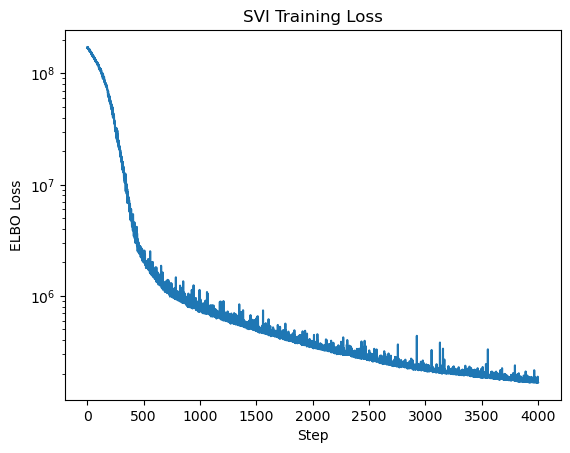

In [43]:
# plot training loss
import matplotlib.pyplot as plt

plt.style.use('default')
plt.plot(losses)
plt.xlabel("Step")
plt.ylabel("ELBO Loss")
# log scale for y-axis
plt.yscale("log")
plt.title("SVI Training Loss")
plt.show()

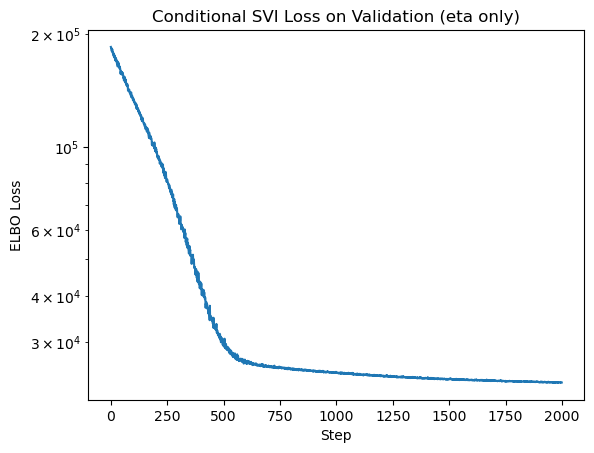

In [44]:
import matplotlib.pyplot as plt

plt.style.use('default')
plt.plot(val_losses)
plt.xlabel("Step")
plt.ylabel("ELBO Loss")
plt.yscale("log")
plt.title("Conditional SVI Loss on Validation (eta only)")
plt.show()


### Reconstruction loss (Only meaningful after inference)

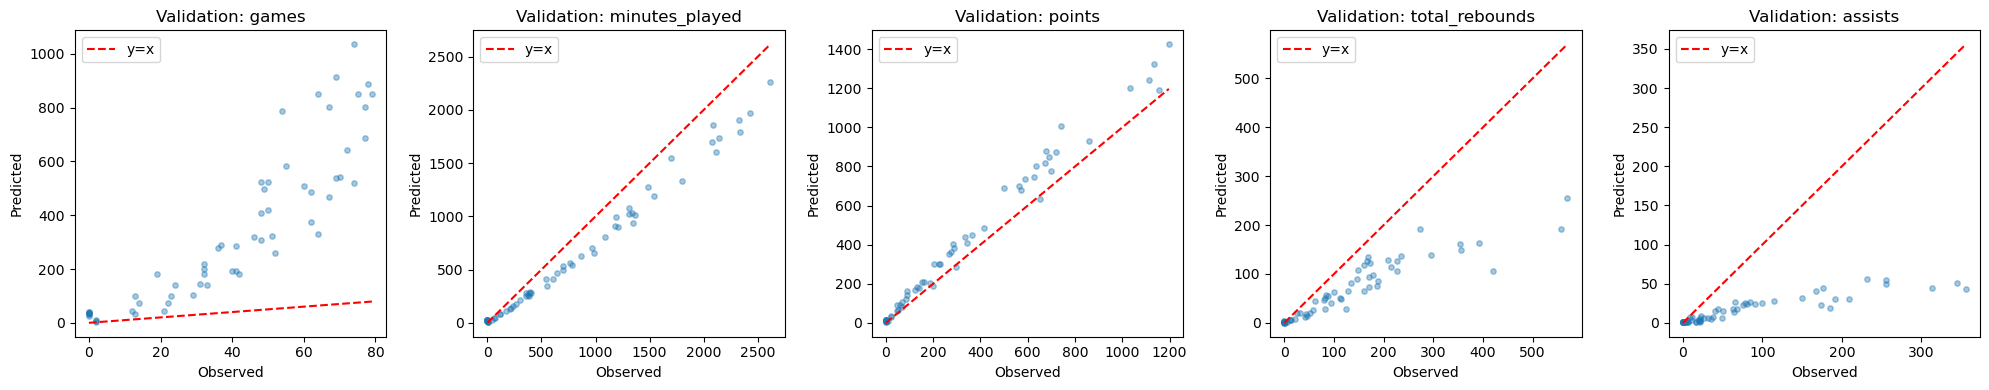

In [ ]:
fig, axes = plt.subplots(1, P, figsize=(4*P, 4))

for i, feat in enumerate(count_features):
    ax = axes[i]
    ax.scatter(X_val_scaled[:, i], rate_val[:, i], alpha=0.4, s=15)
    ax.plot([0, X_val_scaled[:, i].max()],
            [0, X_val_scaled[:, i].max()],
            'r--', label='y=x')
    ax.set_title(f"Validation: {feat}")
    ax.set_xlabel("Observed")
    ax.set_ylabel("Predicted")
    ax.legend()

plt.tight_layout()
plt.show()


### Domain Analysis

In [46]:
# Inference on training set (for comparison)
from numpyro.infer import SVI, Trace_ELBO, Predictive
from numpyro.optim import Adam


# Conditional SVI on ALL DATA
X_all_jax = jnp.asarray(X_all)

lr_eta = 5e-3
num_steps_eta = 2000

guide_eta = AutoDiagonalNormal(style_topic_eta_only_model)
optimizer_eta = Adam(lr_eta)
svi_eta = SVI(
    style_topic_eta_only_model,
    guide_eta,
    optimizer_eta,
    loss=Trace_ELBO(),
)

rng_key_eta = jax.random.PRNGKey(2025)
svi_state_eta = svi_eta.init(
    rng_key_eta,
    X_all_jax,
    K,
    beta_mean,
    gamma_mean,
    log_rate_bias_mean,
    gate_bias_mean,
)

val_losses = []
for step in range(num_steps_eta):
    svi_state_eta, loss_val = svi_eta.update(
        svi_state_eta,
        X_all_jax,
        K,
        beta_mean,
        gamma_mean,
        log_rate_bias_mean,
        gate_bias_mean,
    )
    val_losses.append(float(loss_val))
    if step % 500 == 0:
        print(f"[ALL SVI] step={step}, loss={loss_val:.3f}")

params_eta = svi_eta.get_params(svi_state_eta)

# Posterior for val players
predictive_eta = Predictive(
    style_topic_eta_only_model,
    guide=guide_eta,
    params=params_eta,
    num_samples=500,
)
rng_key_post_eta = jax.random.PRNGKey(2026)
posterior_all = predictive_eta(
    rng_key_post_eta,
    X_all_jax,
    K,
    beta_mean,
    gamma_mean,
    log_rate_bias_mean,
    gate_bias_mean,
)

theta_all = np.array(posterior_all["theta"]).mean(axis=0)       # (N_all, K)
rate_all  = np.array(posterior_all["rate"]).mean(axis=0)        # (N_all, P)
gate_all  = np.array(posterior_all["gate_probs"]).mean(axis=0)  # (N_all, P)

print("theta_all shape:", theta_all.shape)

[ALL SVI] step=0, loss=109725696.000
[ALL SVI] step=500, loss=35728788.000
[ALL SVI] step=1000, loss=27099180.000
[ALL SVI] step=1500, loss=26090436.000
theta_all shape: (1922, 5)


### Style Interpretation 

- **Style 0：低使用率组织型控卫**  
  以助攻为主要贡献、得分与篮板较低、上场时间有限的低使用率组织者。

- **Style 1：高使用率外线得分手**  
  大量上场并承担主要得分任务的外线持球得分型球员。

- **Style 2：篮板主导型内线**  
  以篮板和内线时长为核心特征、进攻以终结为主的传统内线球员。

- **Style 3：全能型球队核心**  
  得分、助攻、篮板和上场时间都极高，承担球队主要攻防职责的多面手核心。

- **Style 4：组织型前锋**  
  以助攻为主要特征、具备前锋体型但承担组织任务的 point-forward 类球员。


In [47]:
K, P = beta_mean.shape
for k in range(K):
    print(f"\n=== Style {k} ===")
    # sort features by loading
    order = np.argsort(-beta_mean[k])  # descending
    for idx in order:
        print(f"{count_features[idx]:20s}  {beta_mean[k, idx]:.3f}")



=== Style 0 ===
assists               0.724
points                0.065
minutes_played        -1.261
games                 -1.342
total_rebounds        -3.450

=== Style 1 ===
games                 2.601
minutes_played        1.642
points                0.376
total_rebounds        -0.164
assists               -3.862

=== Style 2 ===
total_rebounds        6.551
games                 2.434
minutes_played        2.426
points                2.316
assists               -3.918

=== Style 3 ===
points                6.367
minutes_played        6.072
total_rebounds        5.385
assists               5.362
games                 4.857

=== Style 4 ===
assists               4.438
games                 3.890
minutes_played        3.562
total_rebounds        1.702
points                0.899


In [48]:
# Style name mapping (based on your interpretation)
style_names = {
    0: "Low-usage PG / facilitator",
    1: "High-usage perimeter scorer",
    2: "Rebounding big",
    3: "All-around core",
    4: "Point-forward facilitator",
}


In [49]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_player_by_index(
    idx,
    df,
    X,
    theta,
    rate,
    feature_names,
    K,
    style_names=None,
    compare_mode: str = "per_season",
):
    """
    Visualize one player in the latent style model:
      (1) style mixture theta[idx]
      (2) observed vs predicted stats with consistent scale

    Parameters
    ----------
    idx : int
        Row index of the player in df / X.
    df : pd.DataFrame
        DataFrame containing player info, must include 'player', 'year', 'years_active'.
    X : array-like, shape (N, P)
        Observed count features (career totals).
    theta : array-like, shape (N, K)
        Style mixture for each player.
    rate : array-like, shape (N, P)
        Predicted rate (interpreted as per-season totals).
    feature_names : list of str, length P
        Names of the count features in X / rate.
    K : int
        Number of style topics.
    style_names : dict or None
        Optional mapping k -> style name for nicer x-axis labels.
    compare_mode : {"per_season", "career_total"}
        How to compare observed and predicted stats.
        - "per_season": compare observed_per_season vs predicted_per_season (rate).
        - "career_total": compare observed_career vs predicted_career = rate * years_active.
    """
    row = df.iloc[idx]
    player_name = row["player"]
    year = row["year"]
    years_active = float(row.get("years_active", 1.0))

    theta_vec = np.asarray(theta[idx])   # (K,)
    rate_vec  = np.asarray(rate[idx])    # (P,)
    obs_vec   = np.asarray(X[idx], dtype=float)  # (P,)

    # ------------------------
    # 1) Style mixture subplot
    # ------------------------
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    x_styles = np.arange(K)
    ax0 = axes[0]
    ax0.bar(x_styles, theta_vec)
    if style_names is not None:
        x_labels = [style_names.get(k, str(k)) for k in range(K)]
    else:
        x_labels = [str(k) for k in range(K)]
    ax0.set_xticks(x_styles)
    ax0.set_xticklabels(x_labels, rotation=45, ha="right")
    ax0.set_ylim(0, 1.0)
    ax0.set_ylabel("Proportion")
    ax0.set_title(f"Style mixture for {player_name} ({int(year)})")

    # -------------------------------------------------
    # 2) Observed vs predicted with consistent scaling
    # -------------------------------------------------
    if compare_mode == "per_season":
        # Observed per season vs predicted per season (rate)
        # Avoid division by zero just in case.
        years_safe = max(years_active, 1.0)
        obs_plot = obs_vec / years_safe
        pred_plot = rate_vec
        right_title = "Observed vs predicted (per season)"
        legend_obs = "Observed per season"
        legend_pred = "Predicted per season"
    elif compare_mode == "career_total":
        # Predicted career totals = rate * years_active
        obs_plot = obs_vec
        pred_plot = rate_vec * max(years_active, 1.0)
        right_title = "Observed vs predicted (career total)"
        legend_obs = "Observed total"
        legend_pred = "Predicted total"
    else:
        raise ValueError(f"Unknown compare_mode: {compare_mode}")

    x_pos = np.arange(len(feature_names))
    width = 0.35
    ax1 = axes[1]
    ax1.bar(x_pos - width / 2, obs_plot, width=width, label=legend_obs)
    ax1.bar(x_pos + width / 2, pred_plot, width=width, label=legend_pred)
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(feature_names, rotation=45, ha="right")
    ax1.set_title(right_title)
    ax1.legend()

    plt.tight_layout()
    plt.show()


In [50]:
star_indices = {
    "LeBron James": 785,
    "Kobe Bryant": 394,
    "Stephen Curry": 1148,
    "Kyrie Irving": 1262,
    "Tim Duncan": 440,
    "Yao Ming": 728,
}


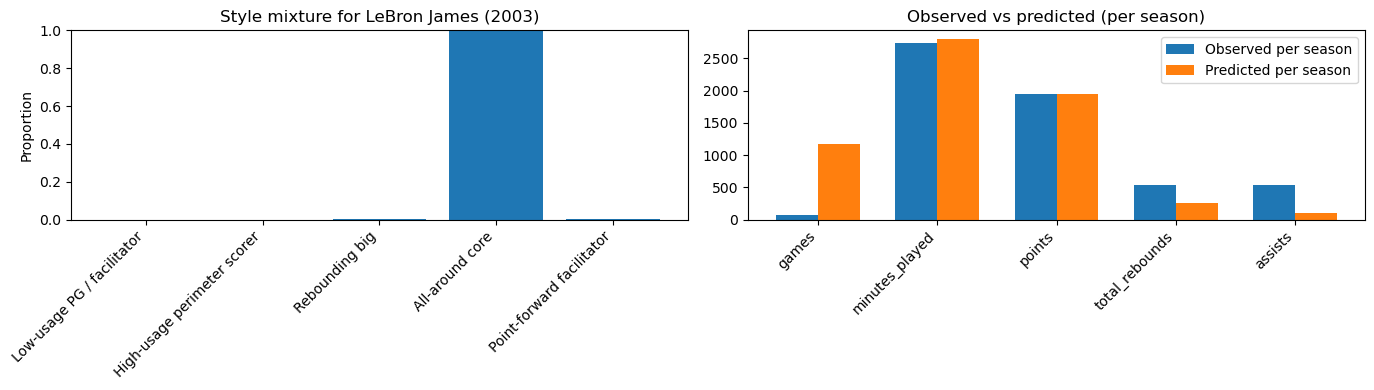

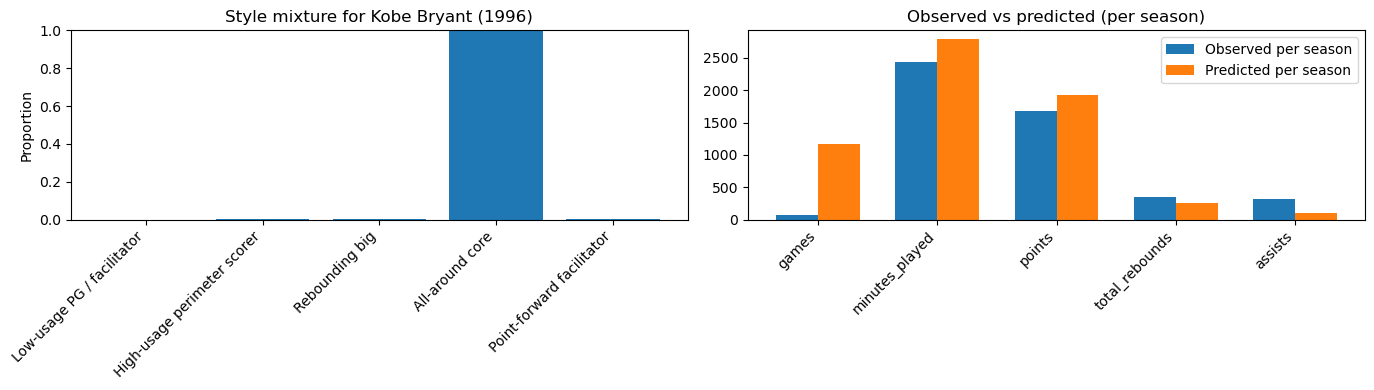

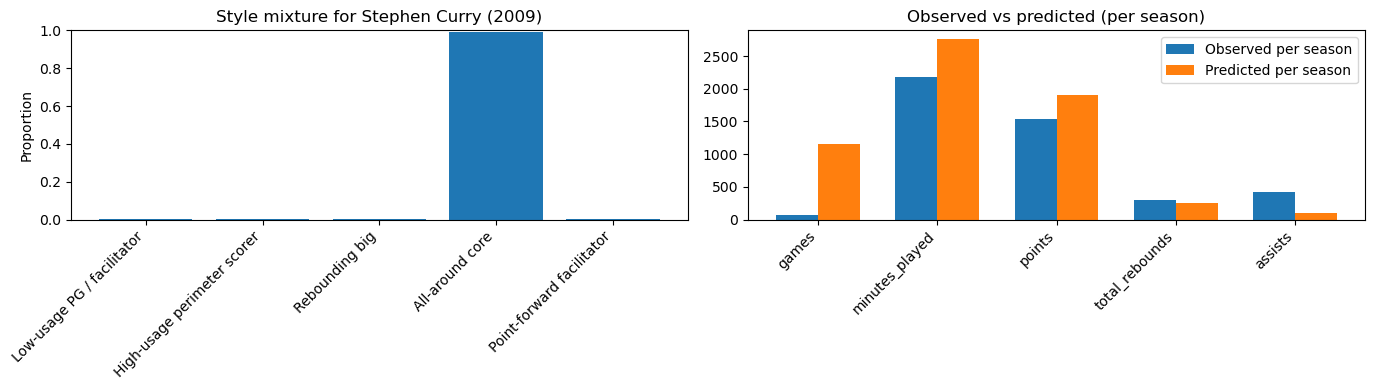

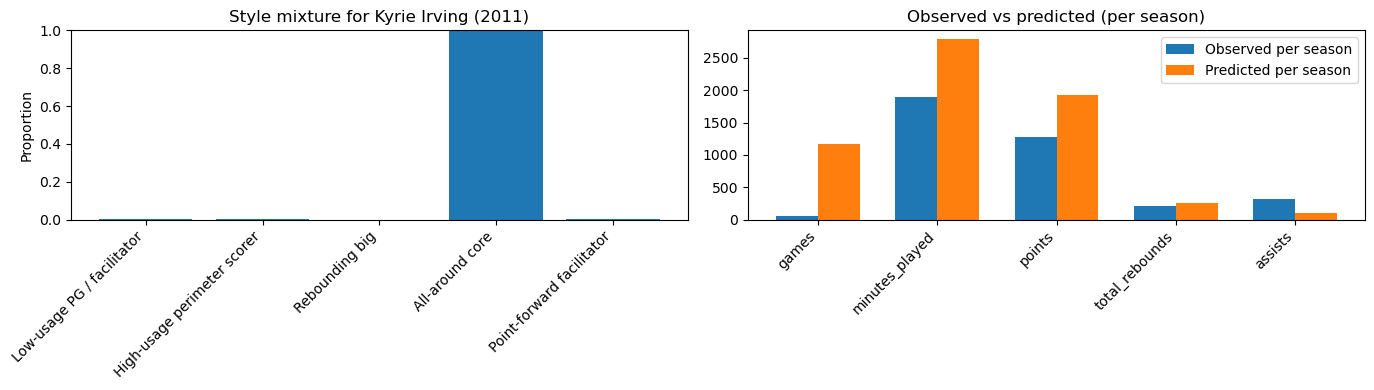

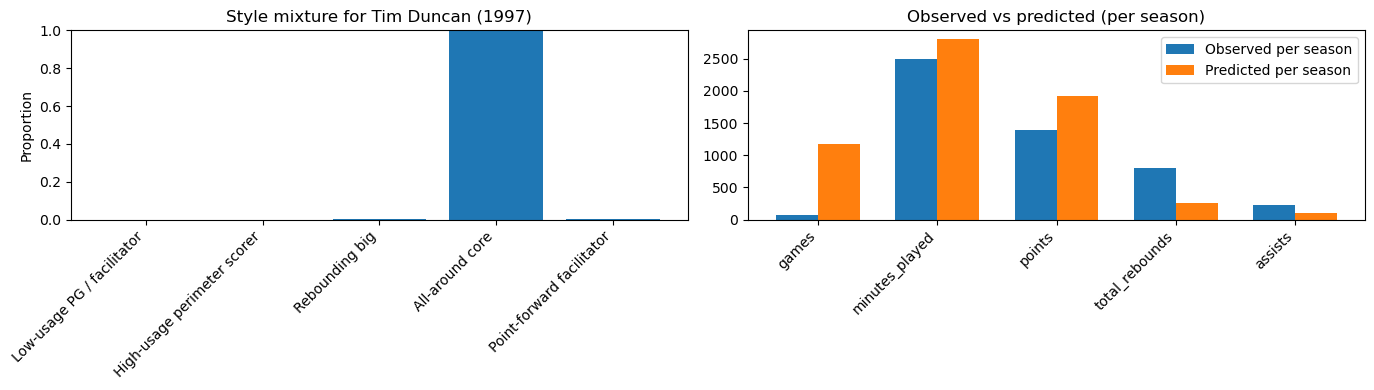

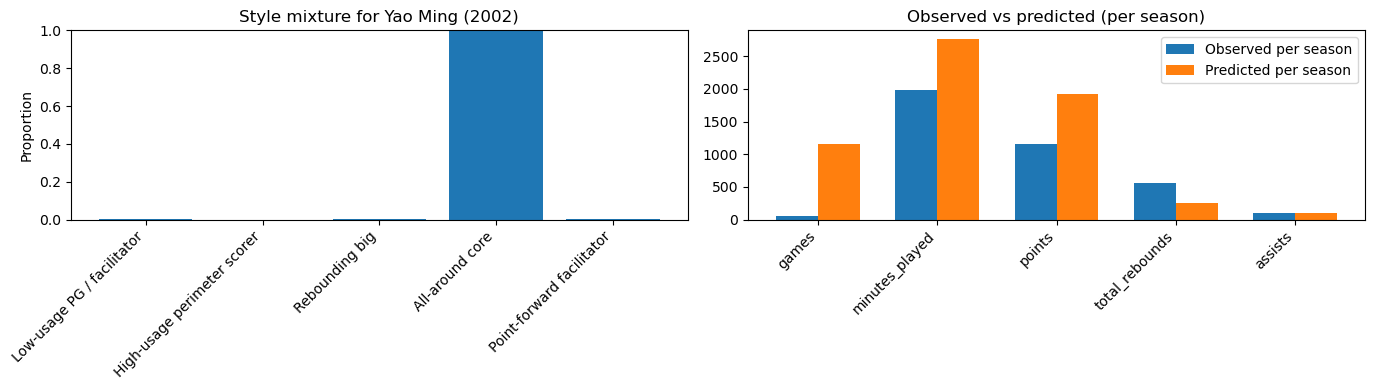

In [51]:
plt.style.use('default')
for name, idx in star_indices.items():
    visualize_player_by_index(
        idx=idx,
        df=train_df,
        X=X_all,
        theta=theta_all,
        rate=rate_all,
        feature_names=count_features,
        K=K,
        style_names=style_names,
    )


**每个风格的杰出球员**

In [54]:
import numpy as np
import pandas as pd

# -------------------------------------------
# Helper: list top-5 players for each style k
# -------------------------------------------

def print_top_players_per_style(theta_all: np.ndarray,
                                players_df: pd.DataFrame,
                                top_n: int = 5) -> None:
    """
    For each style k, print the top-N players with the highest mixture weight θ_{n,k}.

    Parameters
    ----------
    theta_all : array of shape (N, K)
        Posterior mean of style mixture for all players.
    players_df : pd.DataFrame
        Player meta data aligned with theta_all rows. Must contain at least:
        ["player", "year", "team"].
    top_n : int
        Number of top players to show per style.
    """
    N, K = theta_all.shape
    assert len(players_df) == N, "players_df must align with theta_all row-wise."

    for k in range(K):
        # sort players by style-k weight descending
        style_weights = theta_all[:, k]
        top_idx = np.argsort(style_weights)[::-1][:top_n]

        print(f"\n================ Style {k} — Top {top_n} players ================")
        # build a small table for display
        top_table = players_df.iloc[top_idx][["player", "year", "team"]].copy()
        top_table[f"theta_style_{k}"] = style_weights[top_idx]
        # sort again inside the table (just to be safe)
        top_table = top_table.sort_values(by=f"theta_style_{k}", ascending=False)

        print(top_table.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

# align players_df with theta_all rowwise
players_df = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)
print_top_players_per_style(theta_all, players_df, top_n=5)



================ Style 0 — Top 5 players ================
          player  year team  theta_style_0
   David Johnson  2021  TOR          0.962
   Tyson Wheeler  1998  TOR          0.935
Michael McDonald  1995  GSW          0.921
      Gani Lawal  2010  PHO          0.892
   JamesOn Curry  2007  CHI          0.884

================ Style 1 — Top 5 players ================
         player  year team  theta_style_1
    Tiny Gallon  2010  MIL          0.394
  Terrico White  2010  DET          0.390
Isaïa Cordinier  2016  ATL          0.384
    David Young  2004  SEA          0.384
  Emir Preldžić  2009  PHO          0.381

================ Style 2 — Top 5 players ================
         player  year team  theta_style_2
  A.J. Bramlett  1999  CLE          0.571
  Kosta Perović  2006  GSW          0.529
  Derrick Byars  2007  POR          0.487
Dewan Hernandez  2019  TOR          0.479
   Ike Anigbogu  2017  IND          0.462

================ Style 3 — Top 5 players ================
  

### 调试

In [28]:
theta_mean = theta_all.mean(axis=0)  # (K,)
print("Mean topic weights:", theta_mean)

print("Max per topic:", theta_all.max(axis=0))
print("Min per topic:", theta_all.min(axis=0))

dominant = theta_all.argmax(axis=1)  # (N_all,)
unique, counts = np.unique(dominant, return_counts=True)
print(dict(zip(unique, counts)))

import pandas as pd
X_df = pd.DataFrame(X_train, columns=count_features)  # 或你实际用的列名
print(X_df.describe().T[["mean", "std", "min", "max"]])


Mean topic weights: [0.16396303 0.03770185 0.06369037 0.7032196  0.03142517]
Max per topic: [0.9656064  0.33236936 0.57152534 0.9982313  0.34351587]
Min per topic: [1.0871306e-04 2.3966744e-05 3.8992257e-05 4.3552057e-03 6.9798552e-05]
{np.int64(0): np.int64(343), np.int64(2): np.int64(55), np.int64(3): np.int64(1524)}
                       mean          std  min      max
games            310.676155   326.501730  0.0   1541.0
minutes_played  7502.397959  9684.924210  0.0  52139.0
points          3198.493018  4704.214646  0.0  37062.0
total_rebounds  1337.550483  1953.736807  0.0  15091.0
assists          691.653061  1240.023236  0.0  12091.0


In [17]:
train_df.iloc[star_indices["LeBron James"]]

id                                     786
year                                  2003
rank                                     1
overall_pick                             1
team                                   CLE
player                        LeBron James
college                      International
years_active                          19.0
games                               1366.0
minutes_played                     52139.0
points                             37062.0
total_rebounds                     10210.0
assists                            10045.0
field_goal_percentage                0.505
3_point_percentage                   0.346
free_throw_percentage                0.734
average_minutes_played                38.2
points_per_game                       27.1
average_total_rebounds                 7.5
average_assists                        7.4
win_shares                           249.5
win_shares_per_48_minutes             0.23
box_plus_minus                         8.9
value_over_

### 调优 + model criteria

In [26]:
import jax
import jax.numpy as jnp
import numpy as np
from numpyro.infer import SVI, Trace_ELBO, Predictive
from numpyro.optim import Adam
from numpyro.infer.autoguide import AutoDiagonalNormal


# ---- metrics（和上面那段可以共用，不用重复定义） ----
def summarize_elbo(losses, tail=500):
    losses = np.asarray(losses, dtype=float)
    if len(losses) == 0:
        return np.nan
    t = min(tail, len(losses))
    return float(-losses[-t:].mean())

def compute_zip_rmse(X, rate_mean, gate_mean):
    X = np.asarray(X, dtype=float)
    mu = (1.0 - gate_mean) * rate_mean
    return float(np.sqrt(np.mean((X - mu) ** 2)))


def fit_and_eval_once(
    X_train,
    X_val,
    K,
    lr_global=1e-2,
    lr_eta=5e-3,
    steps_global=2000,
    steps_eta=1000,
    seed=0,
):
    """
    一次完整的 run：
      1) 在 X_train 上训练 global topics
      2) 固定 topics，在 X_val 上 conditional SVI 只推断 eta_val
      3) 返回 train_ELBO, val_ELBO, val_RMSE
    注意：这是一个“额外实验函数”，不会动你上面 main pipeline 的 params。
    """
    # ---------- 1) global SVI on X_train ----------
    X_train_jax = jnp.asarray(X_train)

    guide_g = AutoDiagonalNormal(style_topic_zero_inflated_poisson_model)
    opt_g = Adam(lr_global)
    svi_g = SVI(style_topic_zero_inflated_poisson_model, guide_g, opt_g, loss=Trace_ELBO())

    key_g = jax.random.PRNGKey(seed)
    state_g = svi_g.init(key_g, X_train_jax, K)

    losses_g = []
    for t in range(steps_global):
        state_g, loss_val = svi_g.update(state_g, X_train_jax, K)
        losses_g.append(float(loss_val))

    params_g = svi_g.get_params(state_g)

    # posterior over global params
    pred_g = Predictive(
        style_topic_zero_inflated_poisson_model,
        guide=guide_g,
        params=params_g,
        num_samples=500,
    )
    key_post_g = jax.random.PRNGKey(seed + 1)
    post_train = pred_g(key_post_g, X_train_jax, K)

    beta_mean          = np.array(post_train["beta"]).mean(axis=0)
    gamma_mean         = np.array(post_train["gamma"]).mean(axis=0)
    log_rate_bias_mean = np.array(post_train["log_rate_bias"]).mean(axis=0)
    gate_bias_mean     = np.array(post_train["gate_logit_bias"]).mean(axis=0)

    train_ELBO = summarize_elbo(losses_g, tail=500)

    # ---------- 2) conditional SVI on X_val ----------
    X_val_jax = jnp.asarray(X_val)

    guide_e = AutoDiagonalNormal(style_topic_eta_only_model)
    opt_e = Adam(lr_eta)
    svi_e = SVI(style_topic_eta_only_model, guide_e, opt_e, loss=Trace_ELBO())

    key_e = jax.random.PRNGKey(seed + 2)
    state_e = svi_e.init(
        key_e,
        X_val_jax,
        K,
        beta_mean, gamma_mean,
        log_rate_bias_mean, gate_bias_mean,
    )

    losses_e = []
    for t in range(steps_eta):
        state_e, loss_val = svi_e.update(
            state_e,
            X_val_jax,
            K,
            beta_mean, gamma_mean,
            log_rate_bias_mean, gate_bias_mean,
        )
        losses_e.append(float(loss_val))

    params_e = svi_e.get_params(state_e)

    pred_e = Predictive(
        style_topic_eta_only_model,
        guide=guide_e,
        params=params_e,
        num_samples=200,
    )
    key_post_e = jax.random.PRNGKey(seed + 3)
    post_val = pred_e(
        key_post_e,
        X_val_jax,
        K,
        beta_mean, gamma_mean,
        log_rate_bias_mean, gate_bias_mean,
    )

    rate_val  = np.array(post_val["rate"]).mean(axis=0)
    gate_val  = np.array(post_val["gate_probs"]).mean(axis=0)

    val_ELBO = summarize_elbo(losses_e, tail=200)
    val_RMSE = compute_zip_rmse(X_val, rate_val, gate_val)

    return {
        "K": K,
        "lr_global": lr_global,
        "lr_eta": lr_eta,
        "steps_global": steps_global,
        "steps_eta": steps_eta,
        "train_ELBO": train_ELBO,
        "val_ELBO": val_ELBO,
        "val_RMSE": val_RMSE,
    }


In [27]:
import pandas as pd

# 一个简单的超参数网格，你可以只改 K 就行
K_grid        = [3, 5, 8]
lr_global_grid= [1e-2]
lr_eta_grid   = [5e-3]

results = []
exp_id = 0
for K in K_grid:
    for lr_g in lr_global_grid:
        for lr_e in lr_eta_grid:
            print(f"==== EXP {exp_id}: K={K}, lr_g={lr_g}, lr_e={lr_e} ====")
            metrics = fit_and_eval_once(
                X_train=X_train,
                X_val=X_val,
                K=K,
                lr_global=lr_g,
                lr_eta=lr_e,
                steps_global=2000,
                steps_eta=1000,
                seed=42 + exp_id * 10,
            )
            metrics["exp_id"] = exp_id
            results.append(metrics)
            exp_id += 1

df_tune = pd.DataFrame(results)
df_tune


==== EXP 0: K=3, lr_g=0.01, lr_e=0.005 ====


KeyError: 'log_rate_bias'

In [ ]:
def df_to_markdown_with_best(df, sort_by="val_ELBO", ascending=False):
    df_sorted = df.sort_values(sort_by, ascending=ascending).reset_index(drop=True)
    best_idx = 0
    cols = list(df_sorted.columns)

    header = "| " + " | ".join(cols) + " |"
    sep    = "| " + " | ".join(["---"] * len(cols)) + " |"
    rows = [header, sep]

    for i in range(len(df_sorted)):
        row_vals = []
        for c in cols:
            v = df_sorted.loc[i, c]
            if isinstance(v, float):
                v_str = f"{v:.4f}"
            else:
                v_str = str(v)
            if i == best_idx:
                v_str = f"**{v_str}**"
            row_vals.append(v_str)
        rows.append("| " + " | ".join(row_vals) + " |")

    return "\n".join(rows)


md_table = df_to_markdown_with_best(df_tune, sort_by="val_ELBO", ascending=False)
print(md_table)
